# PUC-Rio  
## Departamento de Engenharia Elétrica  
## ELE2398 — Redes Neurais  

**Aluno:** Carlos Alberto de Souza Moreira Junior  
**Matrícula:** 2612398  

**Professores:** Thiago Medeiros/Marley 


### Lista de Exercícios — Echo State Network

**Base escolhida:** `dryer2.dat` — secador industrial multivariável


Nesta lista, avaliamos o uso de **Echo State Network (ESN)** para previsão de séries temporais e identificação de sistemas. A base escolhida é adequada para esse tipo de modelo porque representa um processo industrial dinâmico, no qual as saídas dependem não apenas das entradas no instante atual, mas também do histórico recente do sistema.

Como a ESN possui pesos internos aleatórios que **não são aprendidos**, a avaliação foi feita com múltiplas sementes aleatórias. Dessa forma, evitamos tirar conclusão a partir de uma única inicialização do reservatório e analisamos tanto o erro médio quanto a estabilidade dos resultados.



In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

np.set_printoptions(precision=4, suppress=True)


---

## Implementação da Echo State Network

Antes de responder aos exercícios, utilizamos a implementação da **Echo State Network disponibilizada no notebook da aula**, preservando a estrutura, as equações de atualização dos estados e o procedimento de treinamento apresentados pelo professor.

Foram acrescentadas apenas funções auxiliares para executar os experimentos com diferentes sementes aleatórias, calcular o RMSE e organizar os resultados em tabelas e gráficos.

A ESN possui:

- pesos de entrada $W_{in}$ aleatórios e fixos;
- pesos recorrentes $W$ aleatórios e fixos;
- estados internos atualizados pelo `leaking_rate`;
- apenas os pesos da camada de saída $W_{out}$ treinados por regressão Ridge.

As equações utilizadas são:

$$
\widetilde{x}(t)=\tanh\left(W_{in}u(t)+Wx(t-1)+b\right),
$$

$$
x(t)=(1-\alpha)x(t-1)+\alpha\widetilde{x}(t),
$$

$$
\widehat{y}(t)=W_{out}[x(t);u(t)].
$$

In [2]:
class EchoStateNetwork:
    """
    Echo State Network (ESN) para identificação de sistemas e previsão de séries temporais.

    Arquitetura:
      - Camada de entrada:    pesos W_in (fixos, aleatórios)
      - Reservatório:         pesos W   (fixos, aleatórios esparsos)
      - Camada de saída:      pesos W_out (TREINADOS via regressão linear)

    Equações:
      x̃(t) = tanh(W_in · u(t) + W · x(t-1) + noise)
      x(t)  = (1 - α) · x(t-1)  +  α · x̃(t)       [leaking rate α]
      ŷ(t)  = W_out · [x(t); u(t)]
    """

    def __init__(
        self,
        n_reservoir: int   = 100,
        spectral_radius: float = 0.9,
        sparsity: float    = 0.1,
        leaking_rate: float = 1.0,
        input_scaling: float = 1.0,
        noise: float       = 1e-5,
        ridge: float       = 1e-6,
        seed: int          = None
    ):
        """
        Parâmetros
        ----------
        n_reservoir    : número de neurônios no reservatório
        spectral_radius: raio espectral da matriz W (controla estabilidade/memória)
        sparsity       : fração de conexões ATIVAS em W  (0 = densa, 1 = vazia)
        leaking_rate   : taxa de vazamento α ∈ (0, 1]; 1.0 = sem vazamento
        input_scaling  : escala dos pesos de entrada W_in
        noise          : ruído de regularização injetado no reservatório
        ridge          : parâmetro de regularização L2 para o readout
        seed           : semente aleatória para reprodutibilidade
        """
        self.n_reservoir     = n_reservoir
        self.spectral_radius = spectral_radius
        self.sparsity        = sparsity
        self.leaking_rate    = leaking_rate
        self.input_scaling   = input_scaling
        self.noise           = noise
        self.ridge           = ridge
        self.seed            = seed
        self.W_out           = None
        self.W               = None
        self.W_in            = None

    # ------------------------------------------------------------------
    # Inicialização dos pesos internos (fixos, não treinados)
    # ------------------------------------------------------------------
    def _init_weights(self, n_inputs: int) -> None:
        rng = np.random.RandomState(self.seed)

        # --- Pesos de entrada  [n_reservoir × n_inputs] ---
        self.W_in = rng.uniform(-1, 1, (self.n_reservoir, n_inputs)) * self.input_scaling

        # --- Pesos do reservatório  [n_reservoir × n_reservoir] ---
        # 1) Gera matriz densa aleatória
        W = rng.uniform(-1, 1, (self.n_reservoir, self.n_reservoir))
        # 2) Aplica esparsidade: zera (1 - sparsity) das conexões
        mask = rng.rand(*W.shape) > self.sparsity
        W[mask] = 0.0
        # 3) Escala para o raio espectral desejado
        eigenvalues = np.linalg.eigvals(W)
        current_sr  = np.max(np.abs(eigenvalues))
        if current_sr > 0:
            W *= self.spectral_radius / current_sr
        self.W = W

        # --- Bias do reservatório ---
        self.b_res = rng.uniform(-0.1, 0.1, self.n_reservoir)

    # ------------------------------------------------------------------
    # Propagação pelo reservatório
    # ------------------------------------------------------------------
    def _run_reservoir(self, X: np.ndarray, washout: int = 50) -> np.ndarray:
        """
        Executa o reservatório e retorna os estados após o washout.

        Parâmetros
        ----------
        X       : entrada [T × n_inputs]
        washout : número de passos iniciais descartados

        Retorna
        -------
        states  : estados do reservatório [(T - washout) × n_reservoir]
        """
        T = X.shape[0]
        x = np.zeros(self.n_reservoir)          # estado inicial
        states = np.zeros((T, self.n_reservoir))
        rng = np.random.RandomState(self.seed)

        for t in range(T):
            u       = X[t]
            pre_act = self.W_in @ u + self.W @ x + self.b_res
            pre_act += self.noise * rng.randn(self.n_reservoir)   # regularização
            x_new   = np.tanh(pre_act)
            # Leaking rate: interpolação entre estado anterior e novo
            x = (1.0 - self.leaking_rate) * x + self.leaking_rate * x_new
            states[t] = x

        return states[washout:]

    # ------------------------------------------------------------------
    # Treinamento (apenas W_out é ajustado)
    # ------------------------------------------------------------------
    def fit(
        self,
        X: np.ndarray,
        y: np.ndarray,
        washout: int = 50
    ) -> 'EchoStateNetwork':
        """
        Treina o readout W_out via Ridge Regression.

        Parâmetros
        ----------
        X       : entradas [T × n_inputs]  ou  [T] para SISO
        y       : saídas   [T × n_outputs] ou  [T] para SISO
        washout : passos iniciais descartados (transiente do reservatório)
        """
        if X.ndim == 1: X = X.reshape(-1, 1)
        if y.ndim == 1: y = y.reshape(-1, 1)

        self._init_weights(X.shape[1])
        self.washout_ = washout

        # Coleta estados do reservatório
        states   = self._run_reservoir(X, washout)         # [T-w × N_res]
        extended = np.hstack([states, X[washout:]])        # concatena entrada
        y_target = y[washout:]                             # alvo correspondente

        # Treinamento: regressão Ridge  (pseudo-inversa regularizada)
        reg = Ridge(alpha=self.ridge, fit_intercept=False)
        reg.fit(extended, y_target)
        self.W_out = reg.coef_                             # [n_outputs × n_ext]
        self._n_ext = extended.shape[1]
        return self

    # ------------------------------------------------------------------
    # Predição
    # ------------------------------------------------------------------
    def predict(self, X: np.ndarray, washout: int = 0) -> np.ndarray:
        """
        Gera predições para novas entradas.

        Parâmetros
        ----------
        X       : entradas de teste
        washout : washout adicional no teste (normalmente 0)
        """
        if X.ndim == 1: X = X.reshape(-1, 1)
        states   = self._run_reservoir(X, washout)
        extended = np.hstack([states, X[washout:]])
        return (extended @ self.W_out.T).squeeze()


# ------------------------------------------------------------------
# Funções utilitárias
# ------------------------------------------------------------------

def rmse(y_true, y_pred):
    """Root Mean Squared Error"""
    return np.sqrt(mean_squared_error(y_true, y_pred))


def avaliar_esn(esn, u_train, y_train, u_test, y_test, washout=50, titulo=''):
    """
    Treina e avalia uma ESN, retornando métricas e plotando resultado.
    """
    esn.fit(u_train, y_train, washout=washout)
    y_pred = esn.predict(u_test)
    erro   = rmse(y_test, y_pred)

    plt.figure(figsize=(12, 3))
    plt.plot(y_test, label='Real', linewidth=1.5)
    plt.plot(y_pred, label='ESN',  linewidth=1.5, linestyle='--')
    plt.title(f'{titulo}  —  RMSE = {erro:.5f}')
    plt.xlabel('Tempo (amostras)')
    plt.ylabel('Saída')
    plt.legend()
    plt.tight_layout()
    plt.show()
    return erro


def avaliar_multiplas_sementes(config, u_train, y_train, u_test, y_test,
                                washout=50, n_runs=15):
    """
    Roda a ESN com `n_runs` sementes diferentes para estimar
    a variabilidade da inicialização aleatória.

    Retorna array de RMSEs.
    """
    erros = []
    for seed in range(n_runs):
        esn = EchoStateNetwork(**config, seed=seed)
        esn.fit(u_train, y_train, washout=washout)
        y_pred = esn.predict(u_test)
        erros.append(rmse(y_test, y_pred))
    erros = np.array(erros)
    print(f"  RMSE médio: {erros.mean():.5f}  |  std: {erros.std():.5f}"
          f"  |  min: {erros.min():.5f}  |  max: {erros.max():.5f}")
    return erros


# ------------------------------------------------------------------
# Funções novas para análise e visualização dos resultados
# ------------------------------------------------------------------

def tabela_resumo(resultados, nome_parametro):
    linhas = []

    for valor, erros in resultados.items():
        linhas.append({
            nome_parametro: valor,
            "RMSE_medio": np.mean(erros),
            "RMSE_std": np.std(erros),
            "RMSE_min": np.min(erros),
            "RMSE_max": np.max(erros)
        })

    return pd.DataFrame(linhas)


print("✅ Implementação da ESN carregada com sucesso!")

✅ Implementação da ESN carregada com sucesso!


---

# Exercício 1 — Base de dados e análise exploratória

1. Escolha uma base de dados presente em https://homes.esat.kuleuven.be/~smc/daisy/daisydata.html (conforme visto em sala de aula) ou no repositório. Faça um gráfico de todas as variáveis do problema para avaliar a dinâmica de cada uma delas.

Escolhemos a base `dryer2.dat`, referente a um secador industrial. Ela possui:

- 867 amostras;
- tempo de amostragem de 10 segundos;
- três variáveis de entrada;
- três variáveis de saída.


In [3]:
# O arquivo local é usado primeiro, garantindo reprodutibilidade.
# Caso ele não esteja na pasta, o código tenta acessar a fonte oficial.

candidatos = [
    Path("dryer2.dat"),
    Path("dryer.dat"),
    Path("dryer2.dat.gz"),
    Path("dryer.dat.gz")
]

arquivo_dados = next(
    (
        caminho
        for caminho in candidatos
        if caminho.exists()
    ),
    None
)

url_daisy = (
    "https://ftp.esat.kuleuven.be/"
    "pub/SISTA/data/process_industry/"
    "dryer2.dat.gz"
)

if arquivo_dados is not None:
    compression = (
        "gzip"
        if arquivo_dados.suffix == ".gz"
        else None
    )

    dryer = pd.read_csv(
        arquivo_dados,
        sep=r"\s+",
        header=None,
        compression=compression
    )

    fonte_dados = str(arquivo_dados)

else:
    try:
        dryer = pd.read_csv(
            url_daisy,
            sep=r"\s+",
            header=None,
            compression="gzip"
        )

        fonte_dados = url_daisy

    except Exception as erro:
        raise FileNotFoundError(
            "Coloque o arquivo dryer2.dat ou dryer2.dat.gz "
            "na mesma pasta deste notebook."
        ) from erro


dryer.columns = [
    "amostra",
    "fuel_flow_rate",
    "hot_gas_exhaust_fan_speed",
    "raw_material_flow_rate",
    "dry_bulb_temperature",
    "wet_bulb_temperature",
    "moisture_content_raw_material"
]

dryer["tempo_s"] = (
    dryer["amostra"] - 1
) * 10

print(f"Fonte usada: {fonte_dados}")
print(f"Dimensão: {dryer.shape}")
display(dryer.head())


Fonte usada: dryer2.dat
Dimensão: (867, 8)


,amostra,fuel_flow_rate,hot_gas_exhaust_fan_speed,raw_material_flow_rate,dry_bulb_temperature,wet_bulb_temperature,moisture_content_raw_material,tempo_s
0,1.0,-5.941496,18.486037,214.909990,-3.784765,-2.536373,-0.059663,0.0
1,2.0,-5.941496,18.486037,14.603966,-3.808218,-2.612767,0.099624,10.0
2,3.0,-5.941496,18.486037,-145.165050,-3.896871,-2.689039,-0.188356,20.0
3,4.0,-5.941496,18.486037,-215.826600,-4.077698,-2.760334,-0.661060,30.0
4,5.0,-5.941496,18.486037,-229.491220,-4.285383,-2.827439,-0.784796,40.0


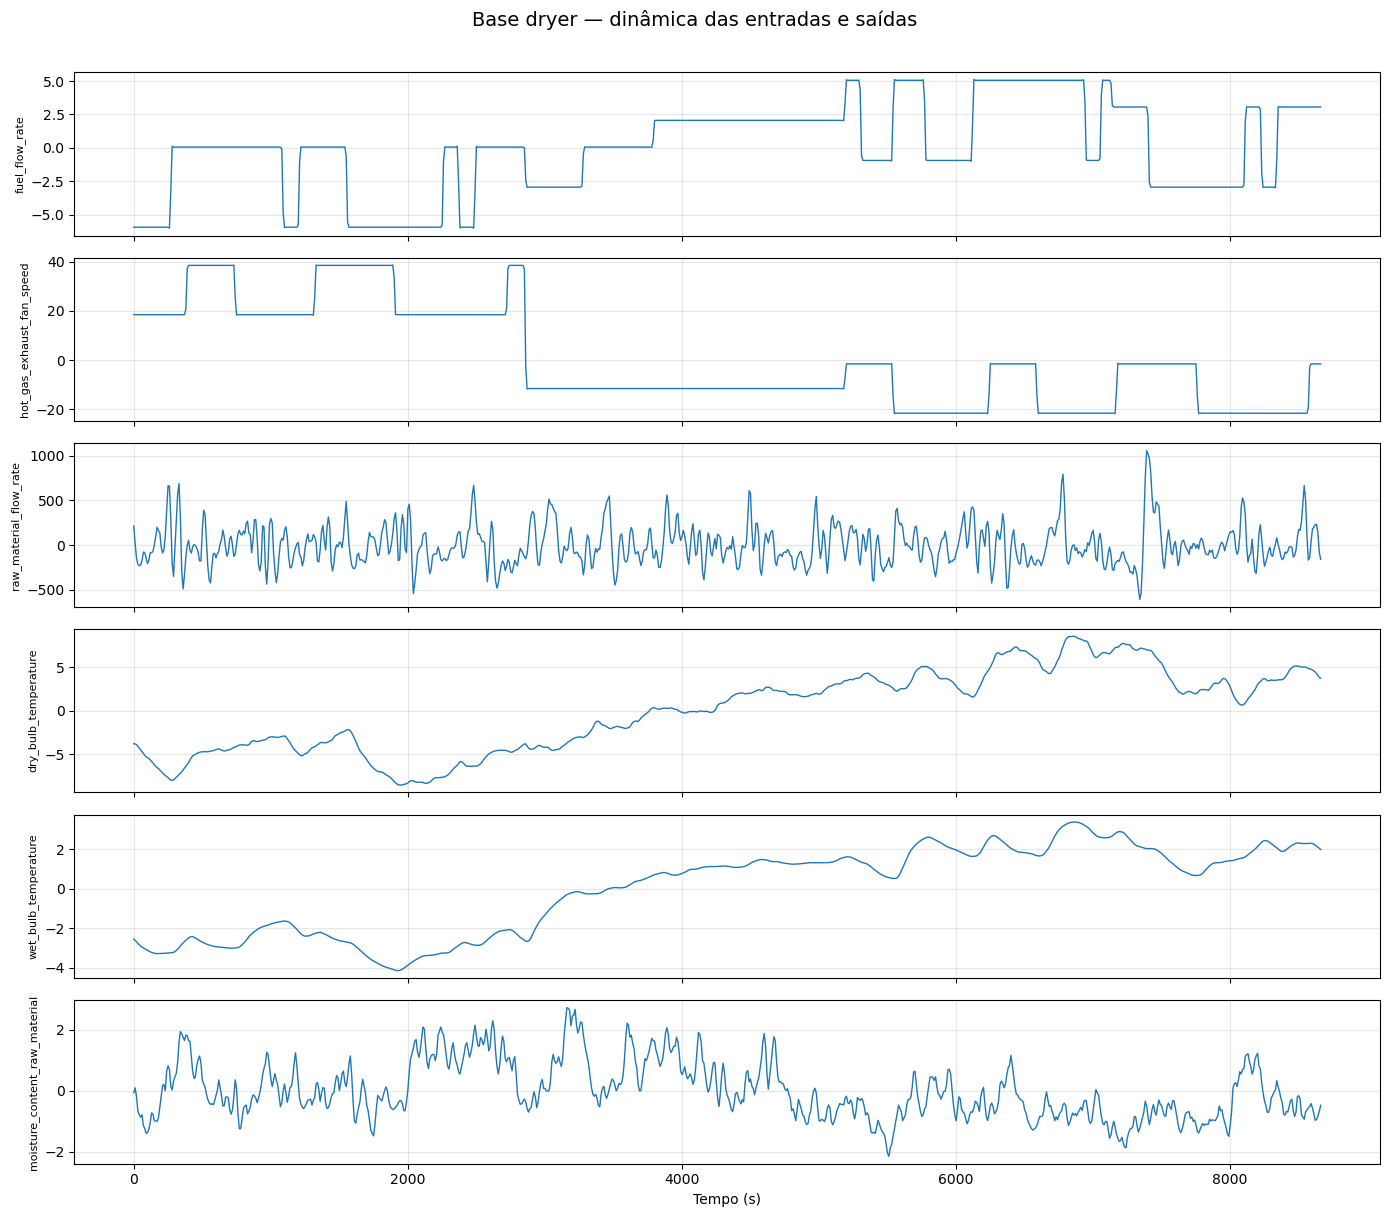

In [4]:
variaveis_entrada = [
    "fuel_flow_rate",
    "hot_gas_exhaust_fan_speed",
    "raw_material_flow_rate"
]

variaveis_saida = [
    "dry_bulb_temperature",
    "wet_bulb_temperature",
    "moisture_content_raw_material"
]

variaveis_todas = (
    variaveis_entrada
    + variaveis_saida
)

U_raw = dryer[
    variaveis_entrada
].to_numpy()

Y_raw = dryer[
    variaveis_saida
].to_numpy()

fig, axes = plt.subplots(
    len(variaveis_todas),
    1,
    figsize=(14, 12),
    sharex=True
)

for ax, coluna in zip(
    axes,
    variaveis_todas
):
    ax.plot(
        dryer["tempo_s"],
        dryer[coluna],
        linewidth=1.0
    )

    ax.set_ylabel(
        coluna,
        fontsize=8
    )

axes[-1].set_xlabel(
    "Tempo (s)"
)

fig.suptitle(
    "Base dryer — dinâmica das entradas e saídas",
    fontsize=14,
    y=1.01
)

plt.tight_layout()
plt.show()


In [5]:
# Divisão temporal: primeiros 70% para treino e últimos 30% para teste.
# A padronização é ajustada somente no treino.

N_TOTAL = len(dryer)
N_TRAIN = int(0.70 * N_TOTAL)
WASHOUT = 50

U_train_raw = U_raw[:N_TRAIN]
U_test_raw = U_raw[N_TRAIN:]

Y_train_raw = Y_raw[:N_TRAIN]
Y_test_raw = Y_raw[N_TRAIN:]

scaler_U = StandardScaler()
scaler_Y = StandardScaler()

u_train = scaler_U.fit_transform(
    U_train_raw
)

u_test = scaler_U.transform(
    U_test_raw
)

y_train = scaler_Y.fit_transform(
    Y_train_raw
)

y_test = scaler_Y.transform(
    Y_test_raw
)

print(
    f"Treino: {len(u_train)} amostras"
)

print(
    f"Teste: {len(u_test)} amostras"
)

print(
    f"Entradas: {u_train.shape[1]}"
)

print(
    f"Saídas: {y_train.shape[1]}"
)


Treino: 606 amostras
Teste: 261 amostras
Entradas: 3
Saídas: 3


### Resposta — Exercício 1


A base possui **867 observações**, três variáveis de entrada e três variáveis de saída. As primeiras 606 observações foram utilizadas para treinamento e as 261 restantes para teste, preservando a ordem temporal da série.

Analisando individualmente as variáveis de entrada, observamos que o **fluxo de combustível** (`fuel_flow_rate`) apresenta comportamento quase constante por intervalos, com mudanças abruptas entre diferentes patamares. Esse comportamento indica alterações no regime de operação do secador.

A **velocidade do ventilador de exaustão** (`hot_gas_exhaust_fan_speed`) também apresenta mudanças em degraus. No início da série, a variável permanece em níveis positivos mais elevados, enquanto, após aproximadamente 2800 segundos, passa a assumir predominantemente valores negativos. Isso sugere que o equipamento foi operado sob diferentes configurações ao longo do experimento.

Já o **fluxo de matéria-prima** (`raw_material_flow_rate`) apresenta uma dinâmica muito mais irregular, com oscilações rápidas e alguns valores extremos. Por volta de 7000 a 7500 segundos, por exemplo, aparecem picos de maior amplitude, indicando variações intensas na alimentação do processo.

Entre as saídas, a **temperatura de bulbo seco** (`dry_bulb_temperature`) apresenta uma trajetória relativamente suave. A série começa próxima de valores negativos, passa por uma redução inicial e depois apresenta uma tendência de crescimento, alcançando seus maiores valores na parte final do experimento.

A **temperatura de bulbo úmido** (`wet_bulb_temperature`) possui comportamento semelhante ao da temperatura de bulbo seco, porém com menor amplitude e oscilações mais amortecidas. A semelhança entre essas duas séries indica que ambas respondem à mesma dinâmica térmica do secador.

O **teor de umidade da matéria-prima** (`moisture_content_raw_material`) apresenta maior variabilidade de curto prazo. Diferentemente das temperaturas, essa variável oscila rapidamente, possui diversos picos e não apresenta uma tendência global tão clara.

Também é possível observar que as alterações abruptas nas entradas não são reproduzidas instantaneamente pelas temperaturas. Enquanto o fluxo de combustível e a velocidade do ventilador mudam rapidamente de nível, as temperaturas respondem de maneira mais gradual e suavizada. Esse comportamento é compatível com a presença de **inércia térmica** e de atraso na resposta do sistema.

Portanto, a saída no instante atual não depende somente das entradas observadas no mesmo instante, mas também dos valores anteriores das entradas e do estado interno do processo. Essa característica justifica o uso de uma **Echo State Network**, pois o reservatório mantém informações do histórico recente e permite representar dependências temporais.

A divisão entre treino e teste foi realizada de forma cronológica, sem embaralhar as observações. Esse procedimento é importante em séries temporais, pois simula uma situação real em que o modelo utiliza o passado para prever períodos posteriores. A padronização também foi ajustada somente com os dados de treinamento, evitando vazamento de informações do conjunto de teste.



---

# Exercício 2 — Configuração inicial de hiperparâmetros

2. Rode o modelo ESN com uma configuração inicial de hiperparâmetros. Justifique a escolha de cada uma delas.




### Resposta — Exercício 2

Para a configuração inicial da Echo State Network, foram utilizados os seguintes hiperparâmetros:

```python
config_base = dict(
    n_reservoir=150,
    spectral_radius=0.95,
    sparsity=0.15,
    leaking_rate=0.20,
    input_scaling=0.50,
    noise=1e-6,
    ridge=1e-4
)
```

A escolha de cada hiperparâmetro é explicada a seguir.

#### Tamanho do reservatório — `n_reservoir = 150`

O parâmetro `n_reservoir` determina a quantidade de neurônios presentes no reservatório da ESN. Quanto maior o reservatório, maior é a quantidade de estados internos disponíveis para representar a dinâmica temporal das entradas.

Foi escolhido um reservatório com 150 neurônios porque esse valor fornece uma quantidade razoável de estados internos, sem tornar o modelo excessivamente grande em relação ao número de observações disponíveis na base.

Reservatórios muito pequenos podem não possuir capacidade suficiente para representar a dinâmica do sistema. Por outro lado, reservatórios muito grandes podem gerar estados redundantes, aumentar o custo computacional e favorecer o sobreajuste da camada de saída.

#### Raio espectral — `spectral_radius = 0.95`

O raio espectral controla a intensidade das conexões recorrentes presentes na matriz $W$. Ele está relacionado ao tempo durante o qual as informações anteriores permanecem influenciando os estados internos do reservatório.

Foi utilizado o valor 0,95, próximo de 1, para permitir que o reservatório mantenha informações anteriores durante um período maior, sem produzir uma dinâmica instável.

Como a base `dryer` representa um processo térmico, espera-se que as entradas não afetem instantaneamente as saídas. Portanto, é importante que o reservatório possua alguma memória dos valores passados.

Valores muito pequenos do raio espectral podem fazer com que a influência das entradas anteriores desapareça rapidamente. Valores muito elevados podem provocar instabilidade ou comportamento excessivamente persistente nos estados internos.

#### Esparsidade — `sparsity = 0.15`

O parâmetro `sparsity` controla a quantidade de conexões recorrentes ativas na matriz $W$.

Foi escolhida uma fração de 15% de conexões ativas, mantendo a matriz recorrente predominantemente esparsa. Essa escolha reduz a quantidade de interações entre os neurônios e, ao mesmo tempo, preserva conexões suficientes para produzir uma dinâmica interna variada.

Uma matriz muito pouco conectada pode limitar a propagação de informação dentro do reservatório. Por outro lado, uma matriz muito densa pode gerar estados redundantes e aumentar a sensibilidade do modelo à inicialização aleatória dos pesos.

#### Taxa de vazamento — `leaking_rate = 0.20`

O parâmetro `leaking_rate`, também representado por $\alpha$, controla a velocidade de atualização dos estados internos:

$$
x(t)=(1-\alpha)x(t-1)+\alpha\widetilde{x}(t).
$$

Com `leaking_rate = 0.20`, o novo estado conserva 80% do estado anterior e incorpora 20% da nova ativação.

Esse valor foi escolhido para produzir uma atualização mais lenta dos estados internos, o que inicialmente parece adequado para um processo térmico, no qual as temperaturas e o teor de umidade tendem a variar de forma gradual.

Valores pequenos fazem com que o reservatório mantenha mais informação do passado. Valores próximos de 1 fazem com que os estados respondam mais rapidamente às novas entradas.

#### Escala das entradas — `input_scaling = 0.50`

O parâmetro `input_scaling` controla a intensidade com que as variáveis de entrada influenciam os neurônios do reservatório.

Foi utilizado o valor 0,50 para evitar que as entradas produzam ativações excessivamente elevadas na função tangente hiperbólica.

Como a função $\tanh$ é limitada entre $-1$ e $1$, entradas muito grandes podem levar os neurônios para regiões de saturação. Nessas regiões, diferentes valores de entrada podem produzir ativações muito semelhantes, reduzindo a capacidade do reservatório de representar as variações da série.

Uma escala moderada permite que os neurônios operem em uma região mais informativa da função de ativação.

#### Ruído — `noise = 1e-6`

O parâmetro `noise` adiciona uma pequena perturbação aleatória durante a atualização dos estados internos do reservatório.

Foi utilizado um valor muito pequeno, igual a $10^{-6}$, para evitar uma alteração relevante na dinâmica original da rede.

A inclusão de uma pequena quantidade de ruído pode ajudar a reduzir comportamentos excessivamente determinísticos e melhorar a robustez numérica do modelo. Entretanto, valores elevados poderiam prejudicar a capacidade de previsão, pois introduziriam variações artificiais nos estados.

#### Regularização Ridge — `ridge = 1e-4`

O parâmetro `ridge` controla a intensidade da regularização aplicada durante o treinamento da camada de saída $W_{out}$.

Na ESN, as matrizes $W_{in}$ e $W$ permanecem fixas. Apenas os pesos da camada de saída são estimados. A regularização Ridge penaliza pesos de saída muito elevados e ajuda a reduzir o risco de sobreajuste.

Foi escolhido o valor $10^{-4}$ por representar uma regularização pequena, mas suficiente para melhorar a estabilidade da estimação dos pesos.

Uma regularização muito baixa pode tornar o modelo sensível aos estados redundantes ou correlacionados. Uma regularização muito elevada pode limitar excessivamente os pesos e provocar subajuste.

#### Washout — `washout = 50`

O `washout` representa a quantidade de observações iniciais descartadas antes do treinamento da camada de saída.

Os primeiros estados do reservatório podem ser muito influenciados pela condição inicial, que normalmente é definida como um vetor de zeros. Por esse motivo, as primeiras 50 observações não são utilizadas na estimação dos pesos de saída.

Esse descarte permite que o reservatório alcance uma dinâmica mais relacionada ao histórico das entradas e menos dependente de sua condição inicial.

Um washout muito pequeno pode manter estados ainda influenciados pela inicialização. Entretanto, um washout muito grande reduz a quantidade de observações disponíveis para o treinamento.

#### Consideração final

A configuração inicial foi escolhida buscando representar a memória e a inércia do processo térmico presente na base `dryer`. Entretanto, essas escolhas representam apenas uma configuração inicial.

O desempenho de cada hiperparâmetro será analisado nos exercícios seguintes, alterando-se um parâmetro por vez e mantendo os demais fixos. Dessa forma, será possível verificar empiricamente quais valores são mais adequados para a base utilizada.


CONFIGURAÇÃO UTILIZADA NO EXEMPLO DA AULA
  RMSE médio: 1.42960  |  std: 0.09895  |  min: 1.23010  |  max: 1.61142

CONFIGURAÇÃO PROPOSTA PARA A BASE DRYER
  RMSE médio: 2.56955  |  std: 0.57109  |  min: 1.67887  |  max: 3.68287


,Configuração,RMSE médio,Desvio-padrão,RMSE mínimo,RMSE máximo
0,Exemplo da aula,1.42960,0.09895,1.23010,1.61142
1,Proposta para a base dryer,2.56955,0.57109,1.67887,3.68287


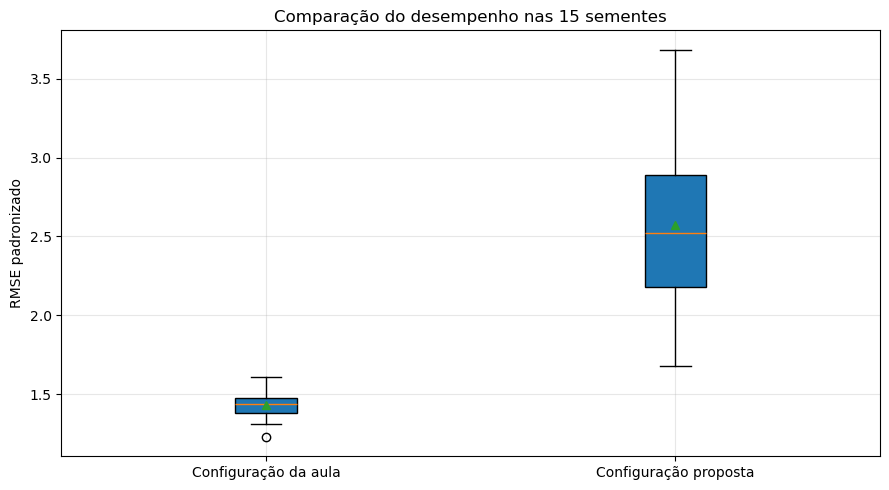

Semente representativa da configuração da aula: 4
Semente representativa da configuração proposta: 1


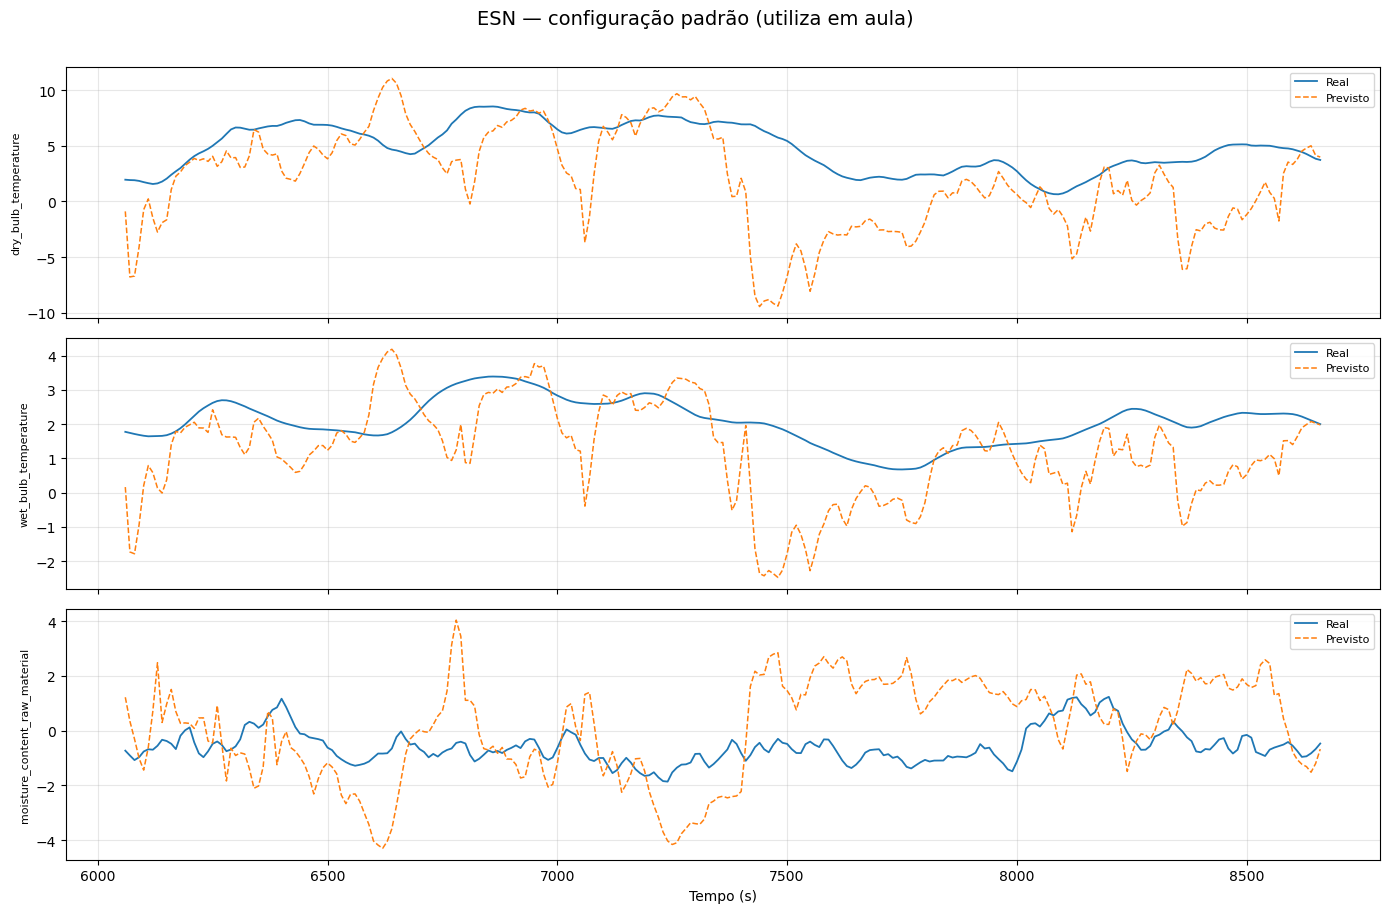

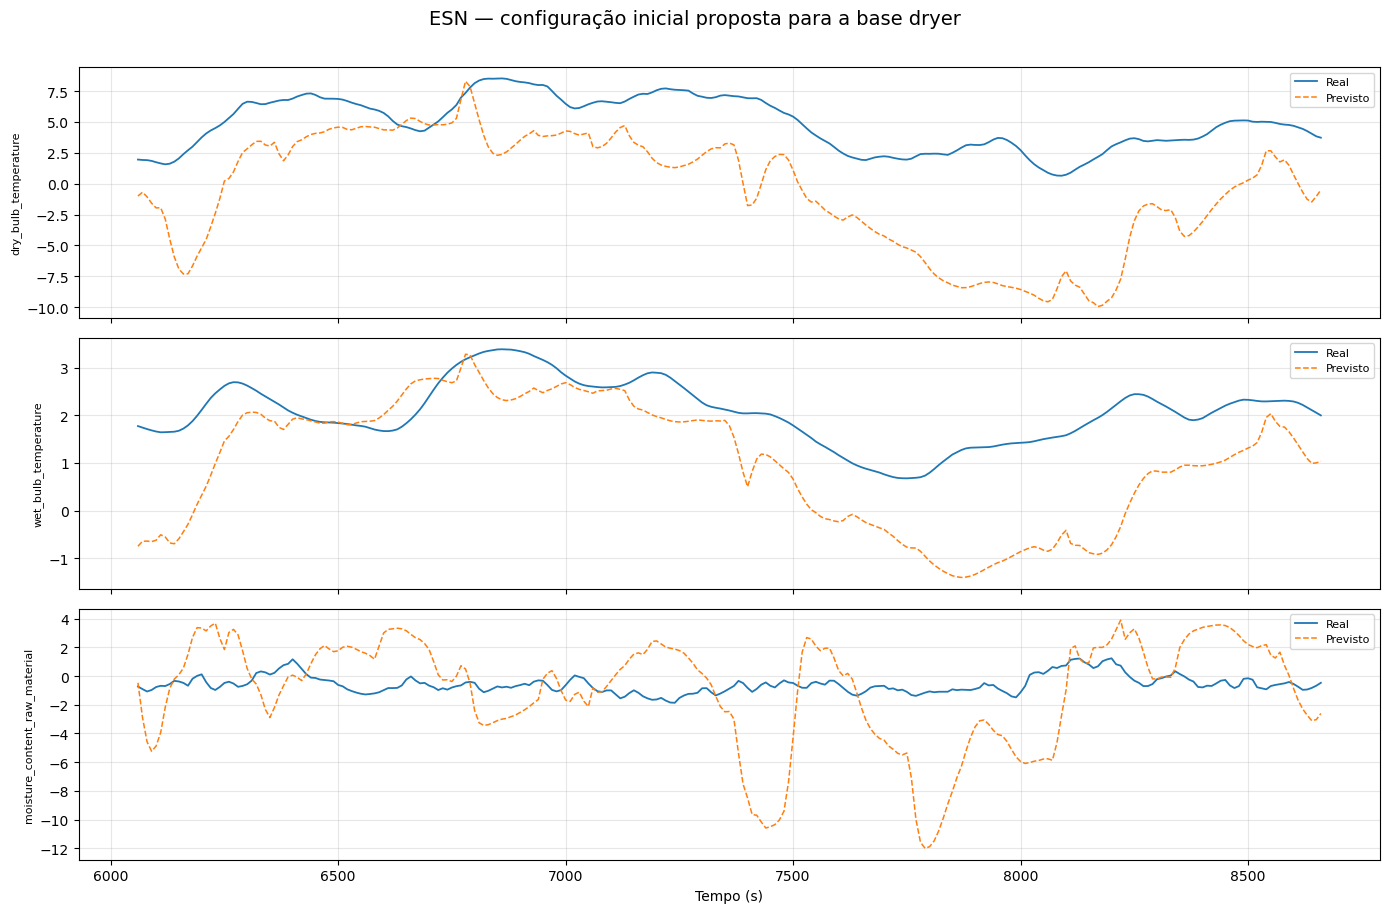

### Síntese dos resultados

A configuração proposta apresentou RMSE médio igual a 2.56955, enquanto a configuração da aula apresentou RMSE médio igual a 1.42960. Houve um aumento aproximado de 79.74% no erro. Portanto, os outputs não corroboraram integralmente a hipótese inicial, mostrando que os valores escolhidos ainda precisam ser investigados separadamente nos próximos exercícios.

- Desvio-padrão da configuração da aula: **0.09895**.
- Desvio-padrão da configuração proposta: **0.57109**.
- Semente representativa da configuração proposta: **1**.

In [11]:

# Configuração apresentada no exemplo da aula
config_aula = dict(
    n_reservoir=100,
    spectral_radius=0.9,
    sparsity=0.1,
    leaking_rate=0.5,
    input_scaling=1.0,
    noise=1e-5,
    ridge=1e-6
)

# Configuração proposta para a dinâmica térmica da base dryer
config_base = dict(
    n_reservoir=150,
    spectral_radius=0.95,
    sparsity=0.15,
    leaking_rate=0.20,
    input_scaling=0.50,
    noise=1e-6,
    ridge=1e-4
)

N_RUNS = 15


# ============================================================
# 1. AVALIAÇÃO COM 15 SEMENTES
# ============================================================

print("=" * 65)
print("CONFIGURAÇÃO UTILIZADA NO EXEMPLO DA AULA")
print("=" * 65)

erros_aula = avaliar_multiplas_sementes(
    config_aula,
    u_train,
    y_train,
    u_test,
    y_test,
    washout=WASHOUT,
    n_runs=N_RUNS
)

print("\n" + "=" * 65)
print("CONFIGURAÇÃO PROPOSTA PARA A BASE DRYER")
print("=" * 65)

erros_base = avaliar_multiplas_sementes(
    config_base,
    u_train,
    y_train,
    u_test,
    y_test,
    washout=WASHOUT,
    n_runs=N_RUNS
)


# ============================================================
# 2. TABELA COMPARATIVA
# ============================================================

comparacao_configuracoes = pd.DataFrame({
    "Configuração": [
        "Exemplo da aula",
        "Proposta para a base dryer"
    ],
    "RMSE médio": [
        erros_aula.mean(),
        erros_base.mean()
    ],
    "Desvio-padrão": [
        erros_aula.std(),
        erros_base.std()
    ],
    "RMSE mínimo": [
        erros_aula.min(),
        erros_base.min()
    ],
    "RMSE máximo": [
        erros_aula.max(),
        erros_base.max()
    ]
})

display(
    comparacao_configuracoes.style.format({
        "RMSE médio": "{:.5f}",
        "Desvio-padrão": "{:.5f}",
        "RMSE mínimo": "{:.5f}",
        "RMSE máximo": "{:.5f}"
    })
)


# ============================================================
# 3. BOXPLOT DOS ERROS DAS 15 SEMENTES
# ============================================================

plt.figure(figsize=(9, 5))

plt.boxplot(
    [erros_aula, erros_base],
    labels=[
        "Configuração da aula",
        "Configuração proposta"
    ],
    patch_artist=True,
    showmeans=True
)

plt.ylabel("RMSE padronizado")
plt.title(
    "Comparação do desempenho nas 15 sementes"
)
plt.grid(
    axis="y",
    alpha=0.3
)
plt.tight_layout()
plt.show()


# ============================================================
# 4. ESCOLHA DE SEMENTES REPRESENTATIVAS
# ============================================================

# Escolhemos a semente cujo erro ficou mais próximo da média.
# Assim, não mostramos somente a melhor execução.

seed_representativa_aula = int(
    np.argmin(
        np.abs(
            erros_aula - erros_aula.mean()
        )
    )
)

seed_representativa_base = int(
    np.argmin(
        np.abs(
            erros_base - erros_base.mean()
        )
    )
)

print(
    "Semente representativa da configuração da aula:",
    seed_representativa_aula
)

print(
    "Semente representativa da configuração proposta:",
    seed_representativa_base
)


# ============================================================
# 5. TREINAMENTO DAS EXECUÇÕES REPRESENTATIVAS
# ============================================================

esn_aula = EchoStateNetwork(
    **config_aula,
    seed=seed_representativa_aula
)

esn_aula.fit(
    u_train,
    y_train,
    washout=WASHOUT
)

y_pred_aula = esn_aula.predict(
    u_test
)

y_pred_aula_original = scaler_Y.inverse_transform(
    y_pred_aula
)


esn_base = EchoStateNetwork(
    **config_base,
    seed=seed_representativa_base
)

esn_base.fit(
    u_train,
    y_train,
    washout=WASHOUT
)

y_pred_base = esn_base.predict(
    u_test
)

y_pred_base_original = scaler_Y.inverse_transform(
    y_pred_base
)

tempo_teste = dryer[
    "tempo_s"
].to_numpy()[N_TRAIN:]


# ============================================================
# 6. GRÁFICOS — CONFIGURAÇÃO DA AULA
# ============================================================

fig, axes = plt.subplots(
    3,
    1,
    figsize=(14, 9),
    sharex=True
)

for indice, nome_saida in enumerate(
    variaveis_saida
):
    axes[indice].plot(
        tempo_teste,
        Y_test_raw[:, indice],
        label="Real",
        linewidth=1.3
    )

    axes[indice].plot(
        tempo_teste,
        y_pred_aula_original[:, indice],
        label="Previsto",
        linewidth=1.1,
        linestyle="--"
    )

    axes[indice].set_ylabel(
        nome_saida,
        fontsize=8
    )

    axes[indice].legend(
        fontsize=8
    )

axes[-1].set_xlabel(
    "Tempo (s)"
)

fig.suptitle(
    "ESN — configuração padrão (utiliza em aula)",
    fontsize=14,
    y=1.01
)

plt.tight_layout()
plt.show()


# ============================================================
# 7. GRÁFICOS — CONFIGURAÇÃO PROPOSTA
# ============================================================

fig, axes = plt.subplots(
    3,
    1,
    figsize=(14, 9),
    sharex=True
)

for indice, nome_saida in enumerate(
    variaveis_saida
):
    axes[indice].plot(
        tempo_teste,
        Y_test_raw[:, indice],
        label="Real",
        linewidth=1.3
    )

    axes[indice].plot(
        tempo_teste,
        y_pred_base_original[:, indice],
        label="Previsto",
        linewidth=1.1,
        linestyle="--"
    )

    axes[indice].set_ylabel(
        nome_saida,
        fontsize=8
    )

    axes[indice].legend(
        fontsize=8
    )

axes[-1].set_xlabel(
    "Tempo (s)"
)

fig.suptitle(
    "ESN — configuração inicial proposta para a base dryer",
    fontsize=14,
    y=1.01
)

plt.tight_layout()
plt.show()


# ============================================================
# 8. CONCLUSÃO AUTOMÁTICA COM BASE NOS OUTPUTS
# ============================================================

diferenca_rmse = (
    erros_aula.mean()
    - erros_base.mean()
)

reducao_percentual = (
    diferenca_rmse
    / erros_aula.mean()
) * 100


if erros_base.mean() < erros_aula.mean():

    conclusao = (
        f"A configuração proposta apresentou RMSE médio "
        f"igual a {erros_base.mean():.5f}, enquanto a "
        f"configuração da aula apresentou RMSE médio igual "
        f"a {erros_aula.mean():.5f}. Isso representa uma "
        f"redução aproximada de {reducao_percentual:.2f}% "
        f"no erro médio. Portanto, os resultados corroboram "
        f"a hipótese de que uma atualização mais lenta dos "
        f"estados e um reservatório moderadamente maior são "
        f"mais adequados à dinâmica térmica da base."
    )

else:

    aumento_percentual = (
        (
            erros_base.mean()
            - erros_aula.mean()
        )
        / erros_aula.mean()
    ) * 100

    conclusao = (
        f"A configuração proposta apresentou RMSE médio "
        f"igual a {erros_base.mean():.5f}, enquanto a "
        f"configuração da aula apresentou RMSE médio igual "
        f"a {erros_aula.mean():.5f}. Houve um aumento "
        f"aproximado de {aumento_percentual:.2f}% no erro. "
        f"Portanto, os outputs não corroboraram integralmente "
        f"a hipótese inicial, mostrando que os valores "
        f"escolhidos ainda precisam ser investigados "
        f"separadamente nos próximos exercícios."
    )


display(
    Markdown(
        "### Síntese dos resultados\n\n"
        + conclusao
        + "\n\n"
        + f"- Desvio-padrão da configuração da aula: "
        + f"**{erros_aula.std():.5f}**.\n"
        + f"- Desvio-padrão da configuração proposta: "
        + f"**{erros_base.std():.5f}**.\n"
        + f"- Semente representativa da configuração proposta: "
        + f"**{seed_representativa_base}**."
    )
)

### Resposta — Exercício 2

A escolha da configuração inicial foi baseada nas características observadas na análise exploratória da base `dryer`, principalmente na resposta suave das temperaturas e na aparente inércia térmica do processo.

A configuração proposta possui:

- 150 neurônios no reservatório;
- raio espectral igual a 0,95;
- aproximadamente 15% de conexões recorrentes ativas;
- `leaking_rate` igual a 0,20;
- `input_scaling` igual a 0,50;
- ruído igual a $10^{-6}$;
- regularização Ridge igual a $10^{-4}$.

O reservatório foi aumentado de 100 para 150 neurônios com o objetivo de ampliar sua capacidade de representação. O raio espectral foi mantido próximo de 1 para preservar por mais tempo a influência dos estados anteriores. Além disso, foi utilizado um `leaking_rate` menor, buscando produzir uma atualização mais lenta dos estados internos, coerente com a dinâmica gradual das temperaturas.

O `input_scaling` foi reduzido para 0,50 para evitar que as entradas padronizadas produzissem ativações excessivamente elevadas na função tangente hiperbólica. A regularização Ridge foi aumentada para $10^{-4}$ com o objetivo de limitar pesos muito elevados na camada de saída.

Como os pesos de entrada e os pesos recorrentes são inicializados aleatoriamente, as duas configurações foram avaliadas utilizando as mesmas 15 sementes.

| Métrica | Configuração da aula | Configuração proposta |
|:---|---:|---:|
| RMSE médio padronizado | **1,42960** | **2,56955** |
| Desvio-padrão | **0,09895** | **0,57109** |
| RMSE mínimo | **1,23010** | **1,67887** |
| RMSE máximo | **1,61142** | **3,68287** |

A configuração proposta apresentou pior desempenho, pois seu RMSE médio aumentou aproximadamente **79,74%** em relação à configuração da aula. Como valores menores de RMSE indicam previsões mais próximas dos valores reais, esse aumento mostra que a nova configuração produziu erros maiores.

O desvio-padrão entre as sementes também aumentou de **0,09895** para **0,57109**. Portanto, além de menos precisa, a configuração proposta foi mais sensível à inicialização aleatória dos pesos.

Outro resultado importante é que o menor RMSE obtido pela configuração proposta, igual a **1,67887**, ainda foi maior que o maior RMSE da configuração da aula, igual a **1,61142**. Assim, nenhuma das 15 execuções da configuração proposta superou as execuções da configuração de referência.

Os gráficos confirmam essa diferença. A configuração da aula acompanha melhor as tendências das temperaturas, embora ainda apresente erros em algumas mudanças de nível. A configuração proposta produz previsões mais afastadas das séries reais e oscilações excessivas, especialmente para o teor de umidade.

Como vários hiperparâmetros foram modificados simultaneamente, não é possível atribuir a piora a apenas um deles. Apesar do desempenho inferior, a configuração proposta foi mantida como `config_base` nos exercícios seguintes para que cada um de seus hiperparâmetros fosse alterado separadamente, mantendo os demais fixos. Dessa forma, foi possível investigar individualmente o efeito do tamanho do reservatório, do `leaking_rate`, da esparsidade e do washout.

---

# Exercício 3 — Tamanho do reservatório

3. Modifique o tamanho do reservatório e avalie o resultado dessa mudança. De que forma a alteração dos pesos pode impactar no resultado final?



── n_reservoir = 10 ──
  RMSE médio: 1.06013  |  std: 0.05275  |  min: 0.96973  |  max: 1.15004

── n_reservoir = 50 ──
  RMSE médio: 1.29356  |  std: 0.17680  |  min: 0.98214  |  max: 1.66560

── n_reservoir = 100 ──
  RMSE médio: 1.99034  |  std: 0.35894  |  min: 1.24942  |  max: 2.61956

── n_reservoir = 200 ──
  RMSE médio: 2.93778  |  std: 0.39906  |  min: 2.31815  |  max: 4.01805

── n_reservoir = 500 ──
  RMSE médio: 3.92442  |  std: 0.78387  |  min: 2.69862  |  max: 5.88732


,n_reservoir,RMSE_medio,RMSE_std,RMSE_min,RMSE_max
0,10,1.060132,0.052749,0.969729,1.150038
1,50,1.293555,0.176804,0.982143,1.665596
2,100,1.990341,0.358938,1.249416,2.619561
3,200,2.937779,0.399055,2.318151,4.018054
4,500,3.924419,0.783873,2.698624,5.887317


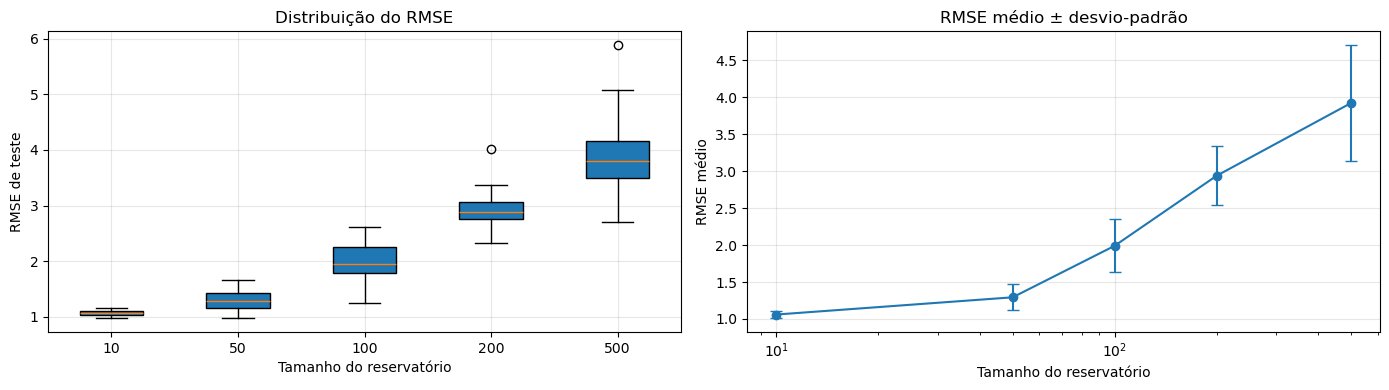

**Melhor tamanho testado:** 10 neurônios, com RMSE médio = **1.06013**.

In [7]:
tamanhos = [
    10,
    50,
    100,
    200,
    500
]

resultados_tamanho = {}

for n_reservatorio in tamanhos:
    config = {
        **config_base,
        "n_reservoir": n_reservatorio
    }

    print(
        f"\n── n_reservoir = "
        f"{n_reservatorio} ──"
    )

    erros = avaliar_multiplas_sementes(
        config,
        u_train,
        y_train,
        u_test,
        y_test,
        washout=WASHOUT,
        n_runs=N_RUNS
    )

    resultados_tamanho[
        n_reservatorio
    ] = erros


tabela_tamanho = tabela_resumo(
    resultados_tamanho,
    "n_reservoir"
)

display(
    tabela_tamanho.sort_values(
        "RMSE_medio"
    )
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 4)
)

axes[0].boxplot(
    [
        resultados_tamanho[valor]
        for valor in tamanhos
    ],
    labels=[
        str(valor)
        for valor in tamanhos
    ],
    patch_artist=True
)

axes[0].set_xlabel(
    "Tamanho do reservatório"
)

axes[0].set_ylabel(
    "RMSE de teste"
)

axes[0].set_title(
    "Distribuição do RMSE"
)

medias = [
    resultados_tamanho[valor].mean()
    for valor in tamanhos
]

desvios = [
    resultados_tamanho[valor].std()
    for valor in tamanhos
]

axes[1].errorbar(
    tamanhos,
    medias,
    yerr=desvios,
    marker="o",
    capsize=4
)

axes[1].set_xscale(
    "log"
)

axes[1].set_xlabel(
    "Tamanho do reservatório"
)

axes[1].set_ylabel(
    "RMSE médio"
)

axes[1].set_title(
    "RMSE médio ± desvio-padrão"
)

plt.tight_layout()
plt.show()

melhor_linha = tabela_tamanho.loc[
    tabela_tamanho[
        "RMSE_medio"
    ].idxmin()
]

display(
    Markdown(
        f"**Melhor tamanho testado:** "
        f"{int(melhor_linha['n_reservoir'])} neurônios, "
        f"com RMSE médio = "
        f"**{melhor_linha['RMSE_medio']:.5f}**."
    )
)


### Resposta — Exercício 3

Neste experimento, foram avaliados reservatórios com 10, 50, 100, 200 e 500 neurônios, utilizando 15 sementes em cada configuração.

Os resultados obtidos foram:

| Número de neurônios | RMSE médio | Desvio-padrão | RMSE mínimo | RMSE máximo |
|:---:|---:|---:|---:|---:|
| 10 | **1,06013** | **0,05275** | **0,96973** | **1,15004** |
| 50 | **1,29356** | **0,17680** | **0,98214** | **1,66560** |
| 100 | **1,99034** | **0,35894** | **1,24942** | **2,61956** |
| 200 | **2,93778** | **0,39906** | **2,31815** | **4,01805** |
| 500 | **3,92442** | **0,78387** | **2,69862** | **5,88732** |

O melhor resultado foi obtido com o menor reservatório testado, composto por **10 neurônios**, que apresentou RMSE médio de **1,06013**. Essa configuração também apresentou o menor desvio-padrão, igual a **0,05275**, indicando maior estabilidade entre as diferentes inicializações aleatórias.

O aumento do reservatório não melhorou a capacidade de previsão. Pelo contrário, o RMSE médio cresceu continuamente à medida que o número de neurônios aumentou. Com 500 neurônios, o RMSE médio chegou a **3,92442**, valor aproximadamente **270% maior** que o obtido com 10 neurônios.

O boxplot também mostra maior dispersão entre as sementes nos reservatórios maiores. Para 500 neurônios, os erros variaram entre **2,69862** e **5,88732**, enquanto, para 10 neurônios, ficaram entre **0,96973** e **1,15004**.

O aumento do número de neurônios modifica as dimensões das matrizes $W_{in}$ e $W$. A matriz $W_{in}$ passa a possuir mais pesos ligando as entradas aos neurônios, enquanto a matriz recorrente $W$ cresce quadraticamente. Como esses pesos são gerados aleatoriamente e permanecem fixos durante o treinamento, cada tamanho produz uma representação interna diferente da série.

Em princípio, um reservatório maior fornece mais estados internos e pode representar dinâmicas mais complexas. Entretanto, isso não garante melhor generalização. Nesta aplicação, os reservatórios maiores provavelmente produziram estados redundantes ou fortemente correlacionados. Como o conjunto de treinamento possui 606 observações, um reservatório com 500 neurônios também gera um número elevado de variáveis para o ajuste da camada de saída.

A regularização Ridge utilizada é pequena. A combinação de muitos estados internos, possível redundância entre eles e regularização fraca pode tornar a estimação dos pesos de saída mais sensível às diferentes inicializações do reservatório.

Portanto, aumentar o reservatório não melhorou a ESN neste experimento. Entre os valores testados e mantendo os demais hiperparâmetros fixos, o reservatório com **10 neurônios** apresentou o melhor desempenho médio e a maior estabilidade.

---

# Exercício 4 — Leaking Rate

4. Modifique o parâmetro de **leaking rate** e avalie o resultado dessa mudança. De que forma a alteração desse hiperparâmetro pode impactar no resultado final?

O parâmetro $\alpha$ aparece na atualização:

$$
x(t)=(1-\alpha)x(t-1)+\alpha\widetilde{x}(t).
$$



── leaking_rate = 0.1 ──
  RMSE médio: 4.17578  |  std: 0.76496  |  min: 3.09364  |  max: 5.96208

── leaking_rate = 0.3 ──
  RMSE médio: 2.09189  |  std: 0.32883  |  min: 1.49887  |  max: 2.67882

── leaking_rate = 0.5 ──
  RMSE médio: 1.70648  |  std: 0.15230  |  min: 1.42803  |  max: 1.93834

── leaking_rate = 0.7 ──
  RMSE médio: 1.53801  |  std: 0.14120  |  min: 1.26738  |  max: 1.80073

── leaking_rate = 1.0 ──
  RMSE médio: 1.37161  |  std: 0.07345  |  min: 1.26856  |  max: 1.51659


,leaking_rate,RMSE_medio,RMSE_std,RMSE_min,RMSE_max
4,1.0,1.371612,0.073455,1.268559,1.516588
3,0.7,1.538009,0.141197,1.267383,1.800731
2,0.5,1.706476,0.152303,1.428029,1.938336
1,0.3,2.091891,0.328834,1.498873,2.678817
0,0.1,4.175784,0.764959,3.093642,5.962076


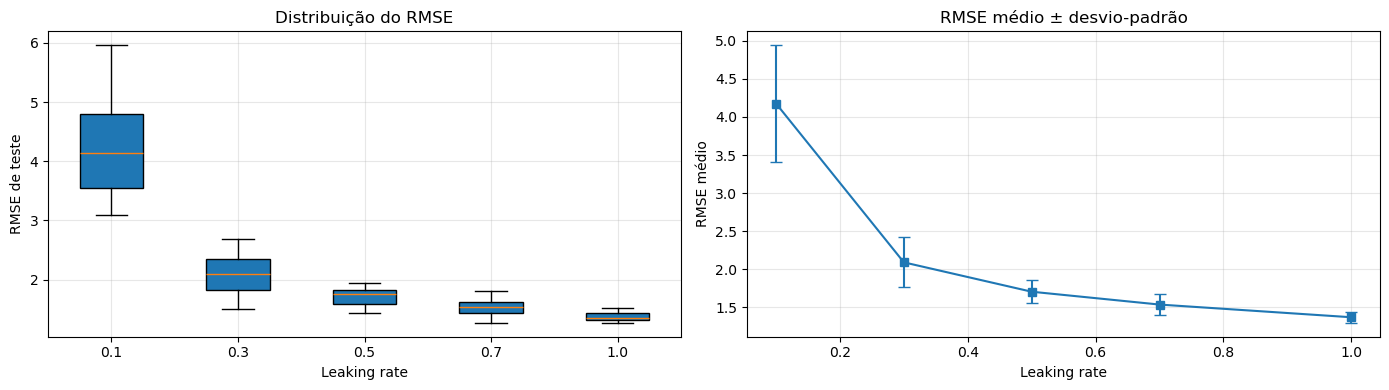

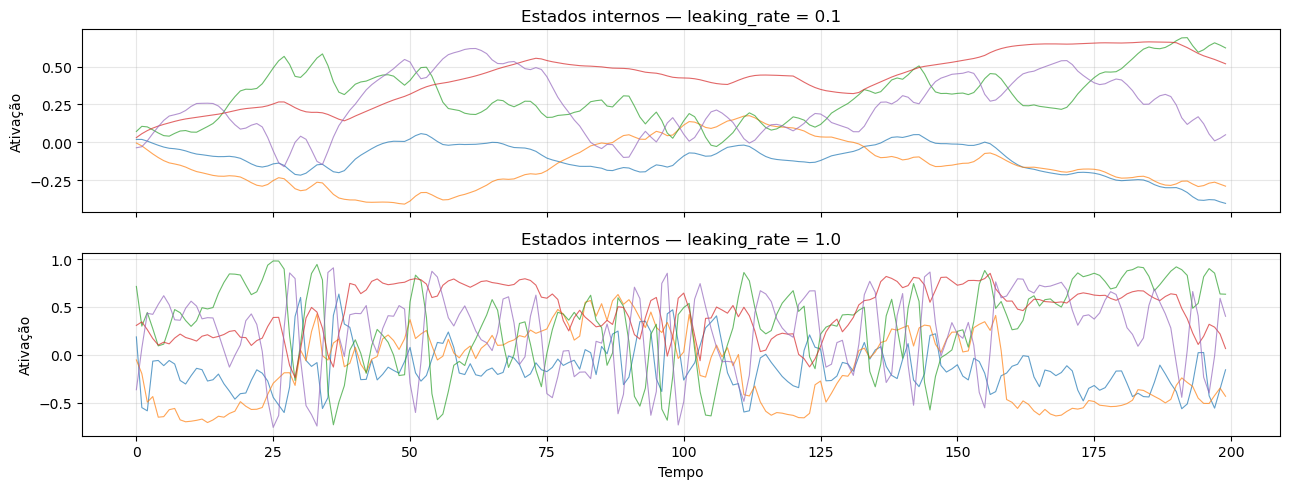

**Melhor leaking rate testado:** 1.00, com RMSE médio = **1.37161**.

In [8]:
leaking_rates = [
    0.1,
    0.3,
    0.5,
    0.7,
    1.0
]

resultados_lr = {}

for leaking_rate in leaking_rates:
    config = {
        **config_base,
        "leaking_rate": leaking_rate
    }

    print(
        f"\n── leaking_rate = "
        f"{leaking_rate} ──"
    )

    erros = avaliar_multiplas_sementes(
        config,
        u_train,
        y_train,
        u_test,
        y_test,
        washout=WASHOUT,
        n_runs=N_RUNS
    )

    resultados_lr[
        leaking_rate
    ] = erros


tabela_lr = tabela_resumo(
    resultados_lr,
    "leaking_rate"
)

display(
    tabela_lr.sort_values(
        "RMSE_medio"
    )
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 4)
)

axes[0].boxplot(
    [
        resultados_lr[valor]
        for valor in leaking_rates
    ],
    labels=[
        str(valor)
        for valor in leaking_rates
    ],
    patch_artist=True
)

axes[0].set_xlabel(
    "Leaking rate"
)

axes[0].set_ylabel(
    "RMSE de teste"
)

axes[0].set_title(
    "Distribuição do RMSE"
)

medias = [
    resultados_lr[valor].mean()
    for valor in leaking_rates
]

desvios = [
    resultados_lr[valor].std()
    for valor in leaking_rates
]

axes[1].errorbar(
    leaking_rates,
    medias,
    yerr=desvios,
    marker="s",
    capsize=4
)

axes[1].set_xlabel(
    "Leaking rate"
)

axes[1].set_ylabel(
    "RMSE médio"
)

axes[1].set_title(
    "RMSE médio ± desvio-padrão"
)

plt.tight_layout()
plt.show()


fig, axes = plt.subplots(
    2,
    1,
    figsize=(13, 5),
    sharex=True
)

for indice, leaking_rate in enumerate(
    [0.1, 1.0]
):
    esn_tmp = EchoStateNetwork(
        **{
            **config_base,
            "leaking_rate": leaking_rate
        },
        seed=0
    )

    esn_tmp._init_weights(
        u_train.shape[1]
    )

    estados = esn_tmp._run_reservoir(
        u_train,
        washout=0
    )

    axes[indice].plot(
        estados[:200, :5],
        alpha=0.7,
        linewidth=0.8
    )

    axes[indice].set_title(
        f"Estados internos — "
        f"leaking_rate = {leaking_rate}"
    )

    axes[indice].set_ylabel(
        "Ativação"
    )

axes[-1].set_xlabel(
    "Tempo"
)

plt.tight_layout()
plt.show()

melhor_linha = tabela_lr.loc[
    tabela_lr[
        "RMSE_medio"
    ].idxmin()
]

display(
    Markdown(
        f"**Melhor leaking rate testado:** "
        f"{melhor_linha['leaking_rate']:.2f}, "
        f"com RMSE médio = "
        f"**{melhor_linha['RMSE_medio']:.5f}**."
    )
)


### Resposta — Exercício 4

Neste experimento, o parâmetro `leaking_rate` foi modificado, sendo testados os valores 0,1, 0,3, 0,5, 0,7 e 1,0, com 15 inicializações aleatórias para cada configuração.

Os resultados obtidos foram:

| `leaking_rate` | RMSE médio | Desvio-padrão | RMSE mínimo | RMSE máximo |
|:---:|---:|---:|---:|---:|
| 0,1 | **4,17578** | **0,76496** | **3,09364** | **5,96208** |
| 0,3 | **2,09189** | **0,32883** | **1,49887** | **2,67882** |
| 0,5 | **1,70648** | **0,15230** | **1,42803** | **1,93834** |
| 0,7 | **1,53801** | **0,14120** | **1,26738** | **1,80073** |
| 1,0 | **1,37161** | **0,07345** | **1,26856** | **1,51659** |

Na ESN, o `leaking_rate`, representado por $\alpha$, controla a proporção entre o estado anterior e a nova ativação:

$$
x(t)=(1-\alpha)x(t-1)+\alpha\widetilde{x}(t).
$$

Quando $\alpha$ é pequeno, uma parcela maior do estado anterior é preservada. O reservatório muda mais lentamente e produz estados mais suavizados. Quando $\alpha$ aumenta, a nova ativação recebe maior peso, tornando o reservatório mais sensível às mudanças das entradas.

Os resultados mostram uma redução praticamente monotônica do RMSE médio à medida que o `leaking_rate` aumenta. Com `leaking_rate = 0,1`, o RMSE médio foi **4,17578**, enquanto, com `leaking_rate = 1,0`, caiu para **1,37161**. Isso corresponde a uma redução aproximada de **67,2%**.

A configuração com `leaking_rate = 1,0` também apresentou o menor desvio-padrão, igual a **0,07345**. Portanto, além de produzir o menor erro médio, foi a configuração mais estável entre as 15 inicializações.

Embora o menor erro individual tenha ocorrido com `leaking_rate = 0,7`, cujo RMSE mínimo foi **1,26738**, a diferença em relação ao mínimo de **1,26856** obtido com `leaking_rate = 1,0` é muito pequena. Considerando o RMSE médio, o desvio-padrão e o RMSE máximo, o valor **1,0** apresentou o melhor desempenho global.

Os gráficos dos estados internos ajudam a interpretar esse comportamento. Com `leaking_rate = 0,1`, as trajetórias mudam lentamente, pois cada estado conserva 90% do estado anterior e incorpora apenas 10% da nova ativação. Essa suavização excessiva dificultou o acompanhamento das mudanças presentes nas entradas.

Com `leaking_rate = 1,0`, os estados respondem mais rapidamente às alterações das entradas. Isso não significa ausência completa de memória, pois o estado anterior continua participando da nova ativação por meio do termo recorrente $Wx(t-1)$.

Portanto, entre os valores testados e mantendo os demais hiperparâmetros fixos, **`leaking_rate = 1,0` apresentou o menor RMSE médio e a menor variabilidade**.

---

# Exercício 5 — Esparsidade

**Enunciado:** modifique o parâmetro de esparsidade e avalie o resultado.

5. Modifique o parâmetro de **esparsidade** e avalie o resultado dessa mudança. De que forma a alteração do volume de conexões pode impactar no resultado final?

```python
mask = rng.rand(*W.shape) > self.sparsity
W[mask] = 0.0
```

Assim, `sparsity = 0.10` gera aproximadamente 10% de conexões ativas e 90% de zeros.



── sparsity = 0.01 (1% de conexões ativas) ──
  RMSE médio: 2.08538  |  std: 0.36377  |  min: 1.37832  |  max: 2.72845

── sparsity = 0.05 (5% de conexões ativas) ──
  RMSE médio: 2.78014  |  std: 0.62537  |  min: 1.84214  |  max: 4.05757

── sparsity = 0.1 (10% de conexões ativas) ──
  RMSE médio: 2.92075  |  std: 0.46029  |  min: 2.11243  |  max: 3.45286

── sparsity = 0.2 (20% de conexões ativas) ──
  RMSE médio: 2.56131  |  std: 0.34203  |  min: 1.84064  |  max: 3.27055

── sparsity = 0.5 (50% de conexões ativas) ──
  RMSE médio: 2.80828  |  std: 0.74330  |  min: 1.52047  |  max: 4.45403

── sparsity = 0.9 (90% de conexões ativas) ──
  RMSE médio: 2.57463  |  std: 0.55250  |  min: 1.86439  |  max: 3.80456


,sparsity,RMSE_medio,RMSE_std,RMSE_min,RMSE_max
0,0.01,2.085383,0.363769,1.378319,2.728451
3,0.20,2.561306,0.342025,1.840644,3.270549
5,0.90,2.574632,0.552497,1.864388,3.804558
1,0.05,2.780135,0.625371,1.842138,4.057572
4,0.50,2.808277,0.743303,1.520468,4.454030
2,0.10,2.920747,0.460294,2.112429,3.452864


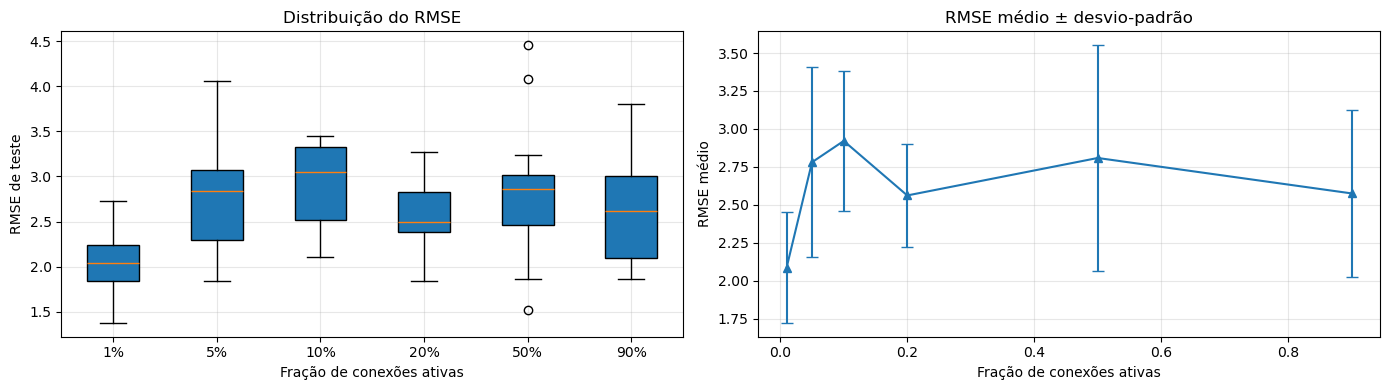

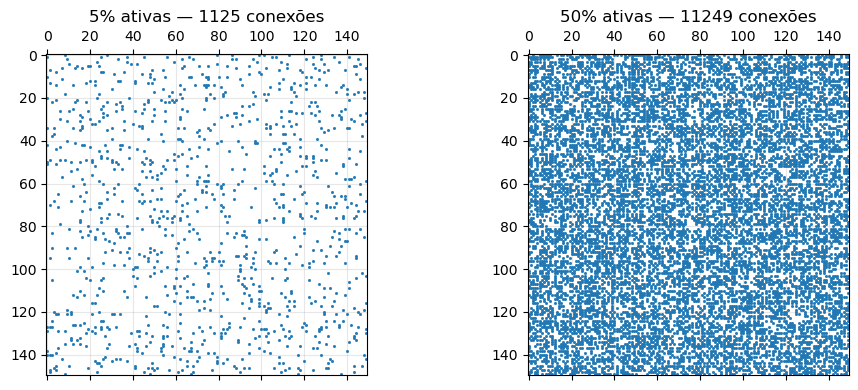

**Melhor fração ativa testada:** 1%, com RMSE médio = **2.08538**.

In [9]:
esparsidades = [
    0.01,
    0.05,
    0.10,
    0.20,
    0.50,
    0.90
]

resultados_esp = {}

for esparsidade in esparsidades:
    config = {
        **config_base,
        "sparsity": esparsidade
    }

    print(
        f"\n── sparsity = "
        f"{esparsidade} "
        f"({esparsidade * 100:.0f}% "
        f"de conexões ativas) ──"
    )

    erros = avaliar_multiplas_sementes(
        config,
        u_train,
        y_train,
        u_test,
        y_test,
        washout=WASHOUT,
        n_runs=N_RUNS
    )

    resultados_esp[
        esparsidade
    ] = erros


tabela_esp = tabela_resumo(
    resultados_esp,
    "sparsity"
)

display(
    tabela_esp.sort_values(
        "RMSE_medio"
    )
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 4)
)

axes[0].boxplot(
    [
        resultados_esp[valor]
        for valor in esparsidades
    ],
    labels=[
        f"{valor:.0%}"
        for valor in esparsidades
    ],
    patch_artist=True
)

axes[0].set_xlabel(
    "Fração de conexões ativas"
)

axes[0].set_ylabel(
    "RMSE de teste"
)

axes[0].set_title(
    "Distribuição do RMSE"
)

medias = [
    resultados_esp[valor].mean()
    for valor in esparsidades
]

desvios = [
    resultados_esp[valor].std()
    for valor in esparsidades
]

axes[1].errorbar(
    esparsidades,
    medias,
    yerr=desvios,
    marker="^",
    capsize=4
)

axes[1].set_xlabel(
    "Fração de conexões ativas"
)

axes[1].set_ylabel(
    "RMSE médio"
)

axes[1].set_title(
    "RMSE médio ± desvio-padrão"
)

plt.tight_layout()
plt.show()


fig, axes = plt.subplots(
    1,
    2,
    figsize=(10, 4)
)

for ax, esparsidade in zip(
    axes,
    [0.05, 0.50]
):
    esn_tmp = EchoStateNetwork(
        **{
            **config_base,
            "sparsity": esparsidade
        },
        seed=0
    )

    esn_tmp._init_weights(
        u_train.shape[1]
    )

    ax.spy(
        esn_tmp.W,
        markersize=1
    )

    numero_conexoes = np.sum(
        esn_tmp.W != 0
    )

    ax.set_title(
        f"{esparsidade:.0%} ativas — "
        f"{numero_conexoes} conexões"
    )

plt.tight_layout()
plt.show()

melhor_linha = tabela_esp.loc[
    tabela_esp[
        "RMSE_medio"
    ].idxmin()
]

display(
    Markdown(
        f"**Melhor fração ativa testada:** "
        f"{melhor_linha['sparsity']:.0%}, "
        f"com RMSE médio = "
        f"**{melhor_linha['RMSE_medio']:.5f}**."
    )
)


### Resposta — Exercício 5

Neste experimento, alteramos o parâmetro `sparsity`. Foram testadas frações de 1%, 5%, 10%, 20%, 50% e 90% de conexões ativas, com 15 inicializações aleatórias para cada configuração.

Os resultados obtidos foram:

| Conexões ativas | RMSE médio | Desvio-padrão | RMSE mínimo | RMSE máximo |
|:---:|---:|---:|---:|---:|
| 1% | **2,08538** | **0,36377** | **1,37832** | **2,72845** |
| 5% | **2,78014** | **0,62537** | **1,84214** | **4,05757** |
| 10% | **2,92075** | **0,46029** | **2,11243** | **3,45286** |
| 20% | **2,56131** | **0,34203** | **1,84064** | **3,27055** |
| 50% | **2,80828** | **0,74330** | **1,52047** | **4,45403** |
| 90% | **2,57463** | **0,55250** | **1,86439** | **3,80456** |

O menor RMSE médio foi obtido com **1% de conexões ativas**, com valor igual a **2,08538**. A pior média ocorreu com **10% de conexões ativas**, cujo RMSE médio foi **2,92075**. Comparando esses dois casos, a configuração com 1% reduziu o erro médio em aproximadamente **28,6%**.

Os resultados não apresentaram uma relação monotônica entre o volume de conexões e o desempenho. O aumento de 1% para 5% e 10% piorou o RMSE, enquanto 20% e 90% produziram resultados intermediários. Portanto, uma matriz mais conectada não foi necessariamente melhor.

A configuração com 50% de conexões ativas apresentou o maior desvio-padrão, igual a **0,74330**, e erros entre **1,52047** e **4,45403**. Isso mostra que algumas inicializações produziram resultados razoáveis, enquanto outras foram muito piores. Assim, uma única execução favorável não deve ser usada para escolher o hiperparâmetro.

Os gráficos das matrizes recorrentes ilustram a diferença estrutural entre as configurações. Com 5% de conexões ativas, foram observadas aproximadamente **1.125 conexões não nulas**. Com 50%, esse número aumentou para aproximadamente **11.249 conexões**, formando uma matriz muito mais densa.

Como o raio espectral foi reajustado em todas as configurações, as diferenças observadas estão associadas principalmente à quantidade e à disposição aleatória das conexões recorrentes. O desempenho depende não apenas do número de conexões, mas também de como elas são distribuídas na matriz $W$.

Portanto, entre os valores testados e para a configuração-base utilizada, **1% de conexões ativas apresentou o menor RMSE médio**. Esse resultado é específico deste experimento e não deve ser interpretado como uma regra geral para todas as ESNs.

---

# Exercício 6 — Tempo de washout

6. Modifique o parâmetro de **tempo de washout** e avalie o resultado dessa mudança. De que forma esta pode impactar no resultado final?

O washout corresponde ao número de estados iniciais descartados antes do ajuste do `readout`.



── washout = 0 amostras ──
  RMSE médio: 2.33945  |  std: 0.41094  |  min: 1.69886  |  max: 3.06656

── washout = 10 amostras ──
  RMSE médio: 2.35664  |  std: 0.42130  |  min: 1.70461  |  max: 3.07294

── washout = 25 amostras ──
  RMSE médio: 2.49116  |  std: 0.52097  |  min: 1.58141  |  max: 3.53729

── washout = 50 amostras ──
  RMSE médio: 2.56955  |  std: 0.57109  |  min: 1.67887  |  max: 3.68287

── washout = 100 amostras ──
  RMSE médio: 2.83242  |  std: 0.63318  |  min: 1.92693  |  max: 4.62019

── washout = 200 amostras ──
  RMSE médio: 3.26248  |  std: 0.69086  |  min: 2.02080  |  max: 4.82864


,washout,RMSE_medio,RMSE_std,RMSE_min,RMSE_max
0,0,2.339451,0.410941,1.698863,3.066555
1,10,2.356640,0.421301,1.704606,3.072945
2,25,2.491162,0.520969,1.581412,3.537295
3,50,2.569547,0.571086,1.678868,3.682874
4,100,2.832417,0.633182,1.926935,4.620193
5,200,3.262483,0.690856,2.020796,4.828639


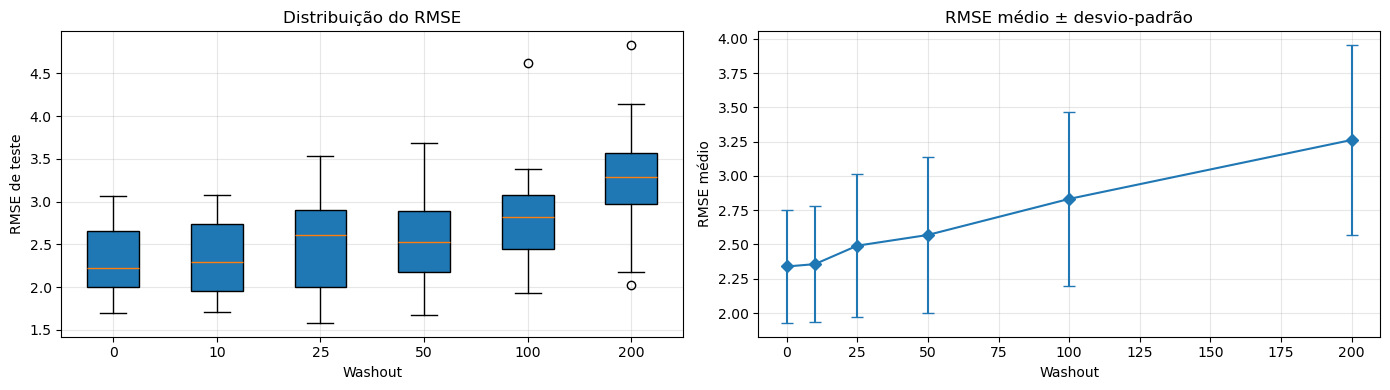

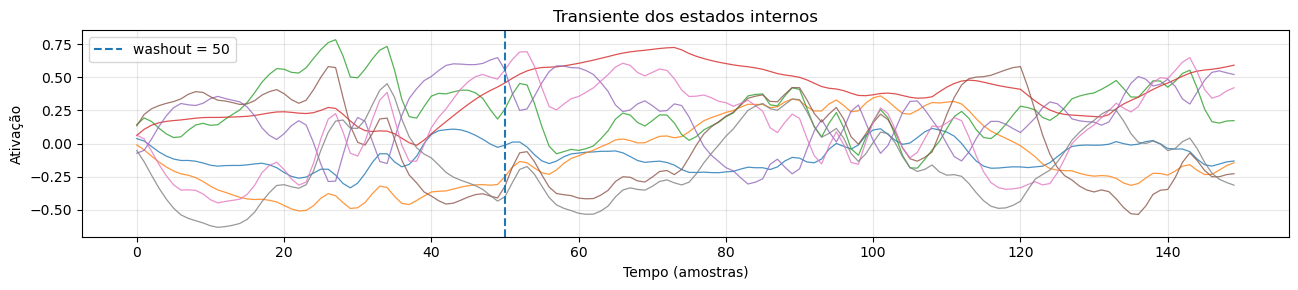

**Melhor washout testado:** 0 amostras, com RMSE médio = **2.33945**.

In [10]:
washouts = [
    0,
    10,
    25,
    50,
    100,
    200
]

resultados_wash = {}

for washout in washouts:
    print(
        f"\n── washout = "
        f"{washout} amostras ──"
    )

    erros = avaliar_multiplas_sementes(
        config_base,
        u_train,
        y_train,
        u_test,
        y_test,
        washout=washout,
        n_runs=N_RUNS
    )

    resultados_wash[
        washout
    ] = erros


tabela_wash = tabela_resumo(
    resultados_wash,
    "washout"
)

display(
    tabela_wash.sort_values(
        "RMSE_medio"
    )
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 4)
)

axes[0].boxplot(
    [
        resultados_wash[valor]
        for valor in washouts
    ],
    labels=[
        str(valor)
        for valor in washouts
    ],
    patch_artist=True
)

axes[0].set_xlabel(
    "Washout"
)

axes[0].set_ylabel(
    "RMSE de teste"
)

axes[0].set_title(
    "Distribuição do RMSE"
)

medias = [
    resultados_wash[valor].mean()
    for valor in washouts
]

desvios = [
    resultados_wash[valor].std()
    for valor in washouts
]

axes[1].errorbar(
    washouts,
    medias,
    yerr=desvios,
    marker="D",
    capsize=4
)

axes[1].set_xlabel(
    "Washout"
)

axes[1].set_ylabel(
    "RMSE médio"
)

axes[1].set_title(
    "RMSE médio ± desvio-padrão"
)

plt.tight_layout()
plt.show()


esn_tmp = EchoStateNetwork(
    **config_base,
    seed=0
)

esn_tmp._init_weights(
    u_train.shape[1]
)

estados = esn_tmp._run_reservoir(
    u_train,
    washout=0
)

plt.figure(
    figsize=(13, 3)
)

plt.plot(
    estados[:150, :8],
    alpha=0.8,
    linewidth=0.9
)

plt.axvline(
    WASHOUT,
    linestyle="--",
    linewidth=1.5,
    label=f"washout = {WASHOUT}"
)

plt.title(
    "Transiente dos estados internos"
)

plt.xlabel(
    "Tempo (amostras)"
)

plt.ylabel(
    "Ativação"
)

plt.legend()
plt.tight_layout()
plt.show()

melhor_linha = tabela_wash.loc[
    tabela_wash[
        "RMSE_medio"
    ].idxmin()
]

display(
    Markdown(
        f"**Melhor washout testado:** "
        f"{int(melhor_linha['washout'])} amostras, "
        f"com RMSE médio = "
        f"**{melhor_linha['RMSE_medio']:.5f}**."
    )
)


### Resposta — Exercício 6

Neste experimento, modificamos o tempo de `washout`. Foram testados os valores 0, 10, 25, 50, 100 e 200 amostras, utilizando 15 inicializações aleatórias em cada configuração.

Os resultados obtidos foram:

| Washout | RMSE médio | Desvio-padrão | RMSE mínimo | RMSE máximo |
|:---:|---:|---:|---:|---:|
| 0 | **2,33945** | **0,41094** | **1,69886** | **3,06656** |
| 10 | **2,35664** | **0,42130** | **1,70461** | **3,07294** |
| 25 | **2,49116** | **0,52097** | **1,58141** | **3,53729** |
| 50 | **2,56955** | **0,57109** | **1,67887** | **3,68287** |
| 100 | **2,83242** | **0,63318** | **1,92693** | **4,62019** |
| 200 | **3,26248** | **0,69086** | **2,02080** | **4,82864** |

O `washout` corresponde à quantidade de estados iniciais descartados antes do treinamento da camada de saída. Como o reservatório começa com estado inicial igual a zero, os primeiros estados podem ser influenciados por essa condição inicial.

O menor RMSE médio foi obtido com **washout igual a 0**, com valor de **2,33945**. O resultado com washout igual a 10 foi muito próximo, apresentando RMSE médio de **2,35664**, apenas cerca de **0,7% maior**.

A partir de 25 amostras, observa-se uma tendência de aumento do erro médio. Com washout igual a 50, o RMSE médio foi **2,56955**. Com 100 amostras, aumentou para **2,83242**, e com 200 amostras alcançou **3,26248**.

A configuração com washout igual a 200 apresentou RMSE médio aproximadamente **39,5% maior** que a configuração sem descarte. Ela também apresentou o maior desvio-padrão, igual a **0,69086**, indicando maior sensibilidade às diferentes inicializações.

Uma possível explicação é a redução da quantidade de dados disponíveis para o treinamento do `readout`. O conjunto de treinamento possui 606 observações. Com washout igual a 200, apenas 406 estados permanecem disponíveis para estimar os pesos da camada de saída.

O gráfico dos estados internos mostra que os neurônios começam a responder às entradas desde o início da sequência. Não se observa uma mudança nítida exatamente na amostra 50 que justifique, para esta base, o descarte dessa quantidade de observações.

Isso não significa que o washout seja desnecessário em todas as aplicações. Seu objetivo é reduzir a influência da condição inicial do reservatório. Entretanto, neste experimento, o benefício de descartar os estados iniciais foi menor que o custo de reduzir a quantidade de dados disponíveis para o treinamento.

Portanto, entre os valores testados, **washout igual a 0 apresentou o menor RMSE médio**. O valor 10 produziu um resultado praticamente equivalente, enquanto washouts elevados aumentaram o erro médio e a variabilidade entre as sementes.

# Conclusão geral

Nesta lista, utilizamos a mesma implementação de **Echo State Network apresentada em aula**, aplicada à base multivariada `dryer`, composta por três variáveis de entrada e três variáveis de saída. A divisão entre treino e teste respeitou a ordem temporal dos dados, e a padronização foi ajustada somente no conjunto de treinamento.

Inicialmente, foi proposta uma configuração diferente daquela utilizada no exemplo da aula, buscando representar a inércia térmica observada no processo. Entretanto, essa configuração apresentou RMSE médio de **2,56955**, enquanto a configuração da aula obteve **1,42960**. Além disso, a configuração proposta apresentou maior variabilidade entre as sementes.

Apesar do desempenho inferior, a configuração proposta foi mantida como `config_base` nos experimentos seguintes. Em cada exercício, apenas um hiperparâmetro foi modificado, enquanto os demais permaneceram fixos. Dessa forma, foi possível analisar individualmente o efeito de cada escolha.

No experimento com o **tamanho do reservatório**, o melhor resultado foi obtido com **10 neurônios**, com RMSE médio de **1,06013**. O aumento do reservatório elevou tanto o erro médio quanto a variabilidade entre as sementes.

Para o **`leaking_rate`**, o melhor desempenho ocorreu com valor igual a **1,0**, que apresentou RMSE médio de **1,37161** e desvio-padrão de **0,07345**. Valores pequenos tornaram a atualização dos estados excessivamente lenta para acompanhar a dinâmica das entradas.

Na análise da **esparsidade**, o menor RMSE médio foi obtido com **1% de conexões recorrentes ativas**, resultando em **2,08538**. Não foi observada uma relação monotônica entre a quantidade de conexões e o desempenho.

No experimento com o **washout**, o menor RMSE médio foi obtido sem descarte de observações, com valor igual a **2,33945**. O resultado com 10 amostras foi muito próximo, mas washouts elevados reduziram a quantidade de dados disponíveis para o treinamento e aumentaram o erro e a variabilidade.

Os principais resultados foram:

| Hiperparâmetro | Melhor valor no experimento isolado | RMSE médio |
|:---|---:|---:|
| Tamanho do reservatório | **10 neurônios** | **1,06013** |
| `leaking_rate` | **1,0** | **1,37161** |
| Conexões recorrentes ativas | **1%** | **2,08538** |
| Washout | **0 amostras** | **2,33945** |

A avaliação com várias sementes foi importante porque as matrizes $W_{in}$ e $W$ são inicializadas aleatoriamente e permanecem fixas durante o treinamento. Em alguns experimentos, uma configuração apresentou uma execução individual favorável, mas desempenho médio e variabilidade piores. Por isso, a escolha dos hiperparâmetros não deve ser baseada apenas no menor erro de uma única semente.

Os melhores valores foram encontrados em experimentos separados. Portanto, não se pode afirmar automaticamente que a combinação de 10 neurônios, `leaking_rate = 1,0`, 1% de conexões ativas e `washout = 0` produzirá a melhor configuração final, pois os hiperparâmetros podem interagir entre si.

De forma geral, os resultados mostraram que uma ESN mais complexa não é necessariamente melhor. Para esta base e para a configuração utilizada como referência nos experimentos, um reservatório pequeno, uma atualização rápida dos estados, uma matriz recorrente bastante esparsa e um washout reduzido apresentaram os melhores resultados entre os valores avaliados.

## Referência da base

De Moor, B. L. R. (ed.). **DaISy: Database for the Identification of Systems**. KU Leuven. Conjunto **Data from an Industrial Dryer**.